## Title

## DataVisualization

In [1]:
#importing  the  libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
#Loading cleaned dataset
df = pd.read_csv("SampleSuperStoreCleaned.csv")
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.shape

(9994, 21)

In [34]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

In [35]:
df["Year"] = df["Order Date"].dt.year

In [36]:
df["Month"] = df["Order Date"].dt.month

## Matplotlib Visualizations

## Sales Trend — Line Chart

In [52]:
import os
os.makedirs("visulizations",exist_ok=True)

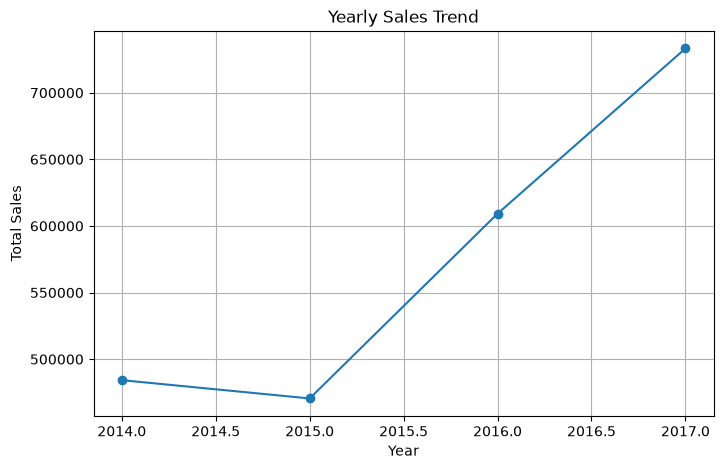

In [39]:
plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker="o")
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.savefig("visualizations/yearly_sales_trend.png")
plt.show()

##  BarChart — Sales by Category

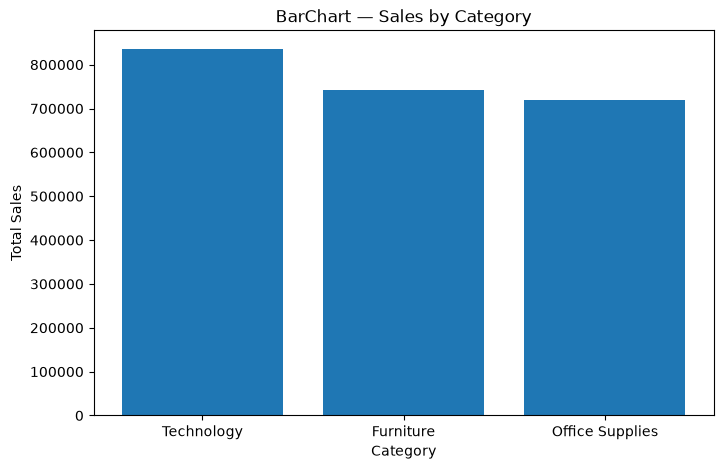

In [40]:
import os
import matplotlib.pyplot as plt

# Create folder if it doesn't exist
os.makedirs("visualizations", exist_ok=True)

# Calculate sales by category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

# Create chart
plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values)

plt.title("BarChart — Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# SAVE IMAGE
plt.savefig("visualizations/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sales vs Profit — Scatter Plot

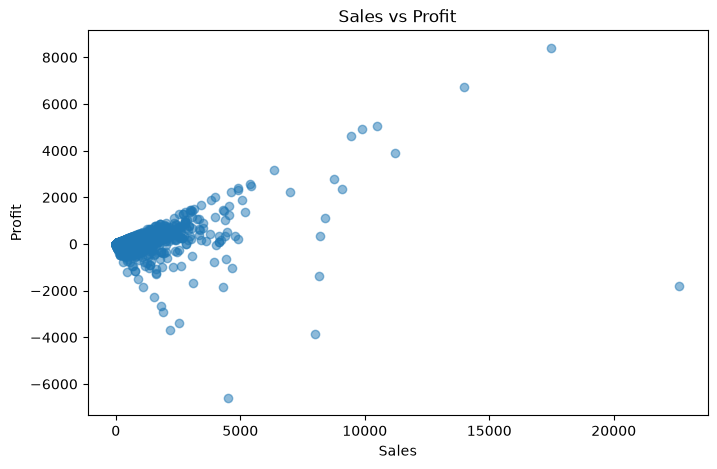

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"], df["Profit"], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.savefig("visualizations/sales_vs_profit.png")
plt.show()

## Sales Distribution — Histogram

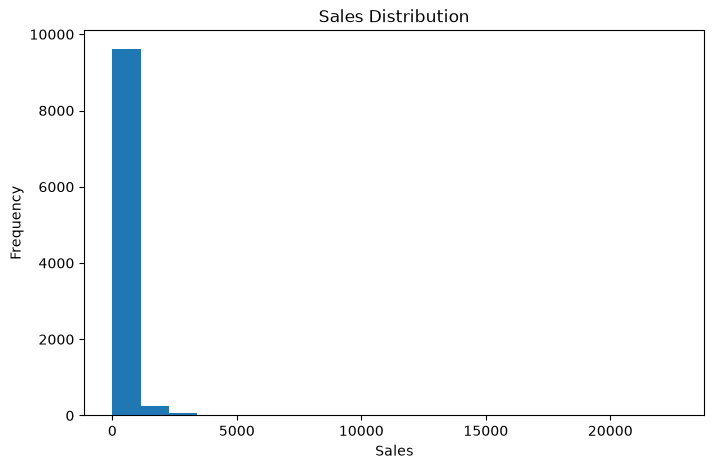

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.savefig("visualizations/sales_distribution.png")
plt.show()

## Seaborn Visualizations

## Heat Map

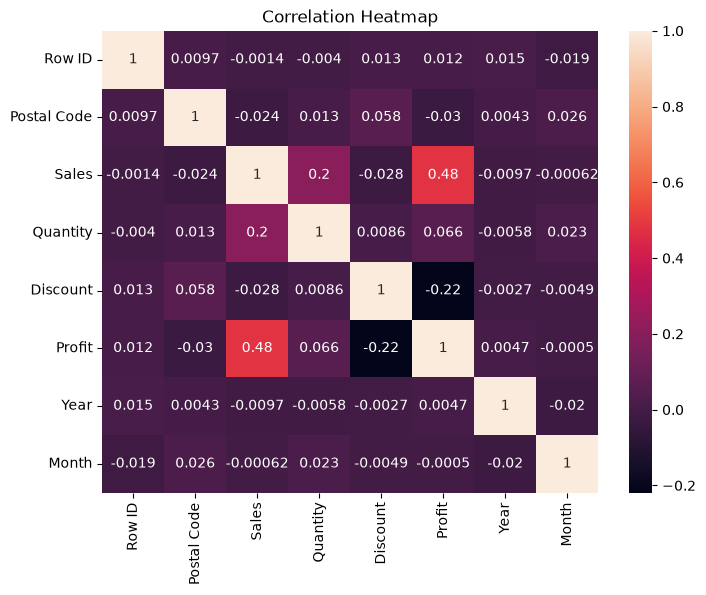

In [43]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.savefig("visualizations/correlation_heatmap.png")
plt.show()

## Pairplot

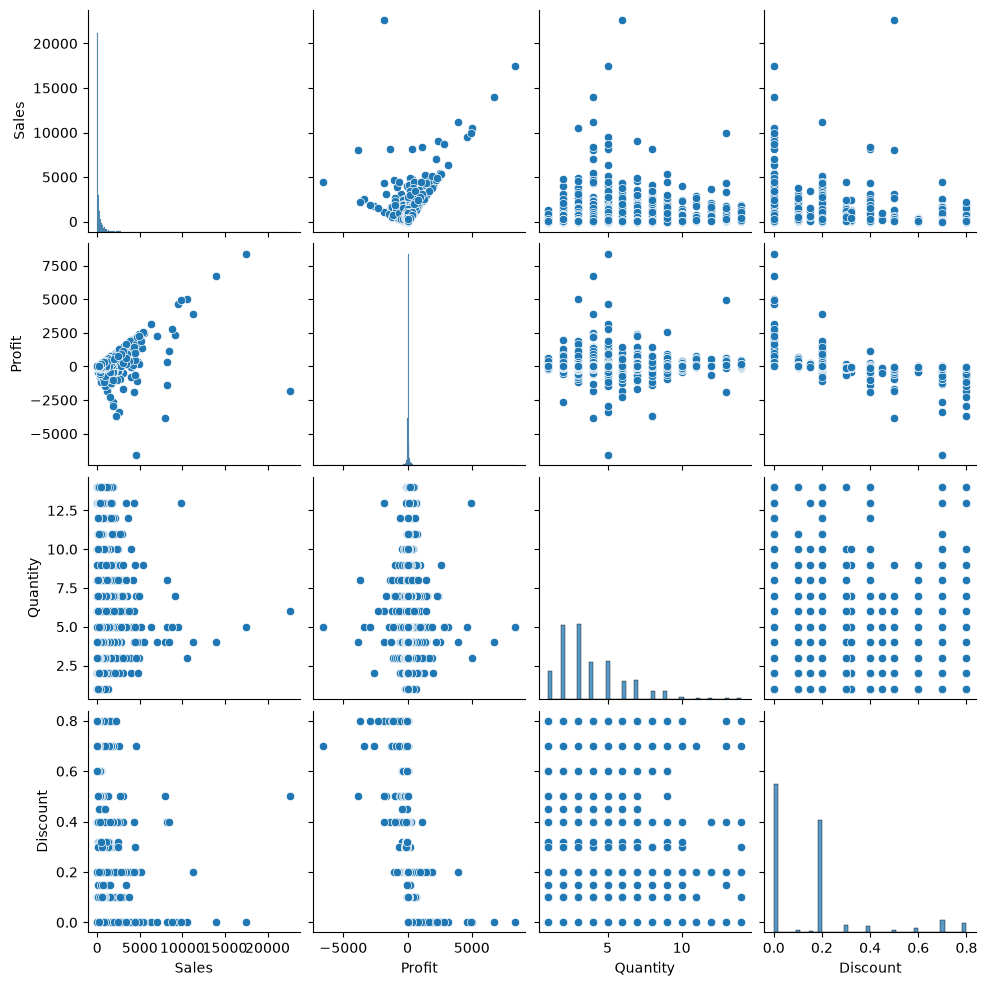

In [44]:
sns.pairplot(df[["Sales", "Profit", "Quantity", "Discount"]])
plt.savefig("visualizations/pairplot.png")
plt.show()

## Boxplot

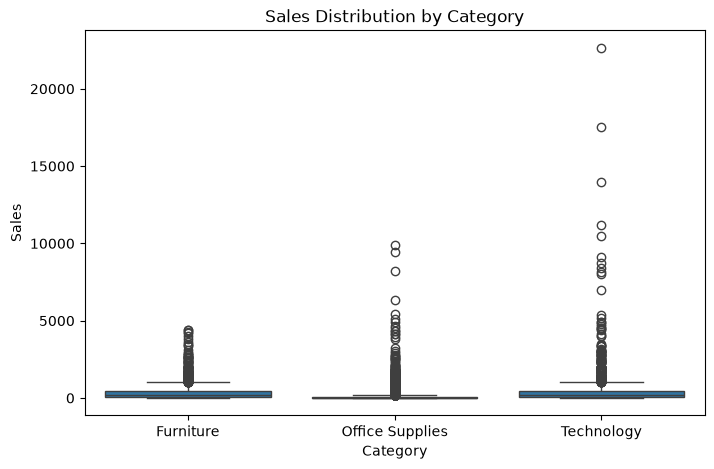

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Category", y="Sales", data=df)

plt.title("Sales Distribution by Category")
plt.savefig("visualizations/category_sales_boxplot.png")
plt.show()

## PLOTLY INTERACTIVE CHART

In [47]:
!pip install plotly

In [48]:
import plotly.express as px

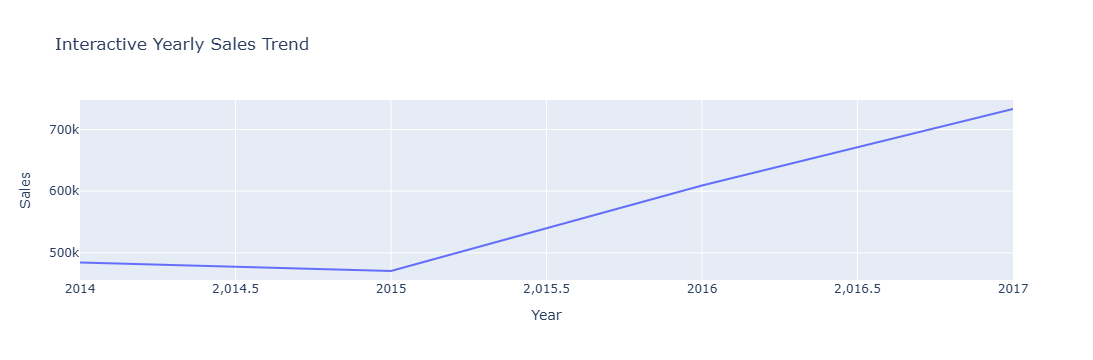

In [49]:
fig = px.line(
    yearly_sales.reset_index(),
    x="Year",
    y="Sales",
    title="Interactive Yearly Sales Trend"
)

fig.show()

In [51]:
fig.write_html("visualizations/interactive_sales_trend.html")